In [1]:
!pip install -q python-igraph scikit-learn ripser persim openTSNE

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.8 MB/s eta 0:00:00


In [2]:
import torch
from torch.utils.data import Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the transformation pipeline:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize the image
    transforms.Lambda(lambda x: x.view(-1))           # Flatten into a 784-dim vector
])

# Load the training set (set download=True if running for the first time)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get indices for images where the label is 1
indices = (mnist_train.targets == 1).nonzero().squeeze()

# Create a subset containing only the '1's
mnist_train_ones = Subset(mnist_train, indices)

print(f"Total number of '1' images in the training set: {len(mnist_train_ones)}")

# Stack all 784-dim vectors from the filtered dataset
all_vectors = torch.stack([img for img, _ in mnist_train_ones])
unique_vectors = torch.unique(all_vectors, dim=0)

print(f"Total images in mnist_train_ones: {all_vectors.shape[0]}")
print(f"Unique images: {unique_vectors.shape[0]}")

if all_vectors.shape[0] == unique_vectors.shape[0]:
    print("All 784-dimensional vectors are unique.")
else:
    print("There are duplicates in the 784-dimensional vectors.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.84MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.80MB/s]


Total number of '1' images in the training set: 6742
Total images in mnist_train_ones: 6742
Unique images: 6726
There are duplicates in the 784-dimensional vectors.


In [3]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import igraph as ig

def build_filtered_knn_graph(unique_vectors, k, max_distance=6.0):
    if hasattr(unique_vectors, 'numpy'):
        X = unique_vectors.numpy()
    else:
        X = unique_vectors

    n = X.shape[0]
    print(f"Building filtered k-NN graph for {n} nodes with edge dist ≤ {max_distance}...")

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    edge_list = []
    for i, (neighbors, dists) in enumerate(zip(indices, distances)):
        for j, dist in zip(neighbors[1:], dists[1:]):  # skip self (index 0)
            if dist <= max_distance and i < j:
                edge_list.append((i, j))

    g = ig.Graph(n=n, edges=edge_list, directed=False)
    print(f"Filtered k-NN graph built with {len(edge_list)} edges.")
    return g

threshold = 6
g_thresh = build_filtered_knn_graph(unique_vectors, k=5, max_distance=threshold)


Building filtered k-NN graph for 6726 nodes with edge dist ≤ 6...
Filtered k-NN graph built with 15068 edges.


In [4]:
components = g_thresh.clusters()
largest_component_index = components.sizes().index(max(components.sizes()))
g_largest = g_thresh.subgraph(components[largest_component_index])
mapping = components[largest_component_index]  # Maps subgraph idx → original idx
print(f"Largest component: {g_largest.vcount()} nodes, {g_largest.ecount()} edges.")


Largest component: 6372 nodes, 15015 edges.


<ipython-input-4-1dcb5f0051b5>:1: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g_thresh.clusters()


In [5]:
dist_matrix = g_largest.shortest_paths()
dist_matrix = np.array(dist_matrix)
max_dist = np.max(dist_matrix)
i, j = np.unravel_index(np.argmax(dist_matrix), dist_matrix.shape)
print(f"Furthest nodes: {i} and {j} with shortest path length {max_dist}")


<ipython-input-5-9fed582e627f>:1: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  dist_matrix = g_largest.shortest_paths()


Furthest nodes: 0 and 6339 with shortest path length 38


In [6]:
# Get the shortest path (as list of node indices)
path = g_largest.get_shortest_paths(i, to=j, output='vpath')[0]

# Reuse original vectors for distance calculation
vectors_np = unique_vectors.numpy()
path_distances = []

for idx in range(len(path) - 1):
    u, v = path[idx], path[idx + 1]
    vec_u = vectors_np[mapping[u]]
    vec_v = vectors_np[mapping[v]]
    dist = np.linalg.norm(vec_u - vec_v)
    path_distances.append(dist)
    print(f"Edge {u} -> {v} | L2 distance: {dist:.4f}")

total_path_distance = sum(path_distances)
print(f"\nTotal L2 distance along path: {total_path_distance:.4f}")


Edge 0 -> 1 | L2 distance: 5.9161
Edge 1 -> 116 | L2 distance: 4.8990
Edge 116 -> 108 | L2 distance: 4.5826
Edge 108 -> 2304 | L2 distance: 4.7958
Edge 2304 -> 2384 | L2 distance: 4.2426
Edge 2384 -> 125 | L2 distance: 4.3589
Edge 125 -> 26 | L2 distance: 5.3852
Edge 26 -> 364 | L2 distance: 5.2915
Edge 364 -> 2664 | L2 distance: 4.8990
Edge 2664 -> 2806 | L2 distance: 5.0000
Edge 2806 -> 557 | L2 distance: 4.6904
Edge 557 -> 849 | L2 distance: 4.5826
Edge 849 -> 842 | L2 distance: 4.3589
Edge 842 -> 1199 | L2 distance: 4.3589
Edge 1199 -> 1182 | L2 distance: 3.7417
Edge 1182 -> 1109 | L2 distance: 3.6056
Edge 1109 -> 1103 | L2 distance: 3.7417
Edge 1103 -> 1549 | L2 distance: 3.7417
Edge 1549 -> 1472 | L2 distance: 4.3589
Edge 1472 -> 1833 | L2 distance: 4.1231
Edge 1833 -> 2208 | L2 distance: 3.7417
Edge 2208 -> 2197 | L2 distance: 3.7417
Edge 2197 -> 5690 | L2 distance: 3.8730
Edge 5690 -> 6186 | L2 distance: 2.4495
Edge 6186 -> 5691 | L2 distance: 3.6056
Edge 5691 -> 6142 | L2 dist

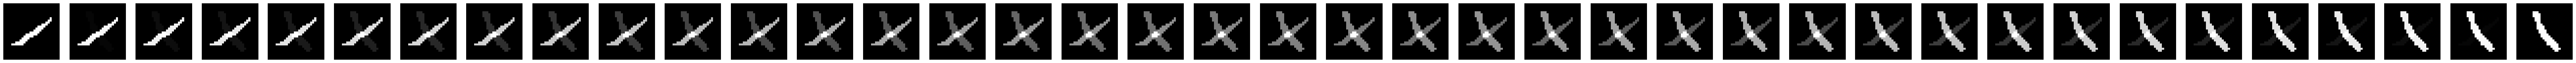

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve the start and end vectors
vec_start = vectors_np[mapping[i]]
vec_end = vectors_np[mapping[j]]

# Number of interpolation steps
num_steps = len(path)

# Generate linear interpolation vectors
linear_path = np.linspace(vec_start, vec_end, num=num_steps)

# Optional: Visualize the interpolated images
fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 2, 2))
for idx, ax in enumerate(axes):
    ax.imshow(linear_path[idx].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()


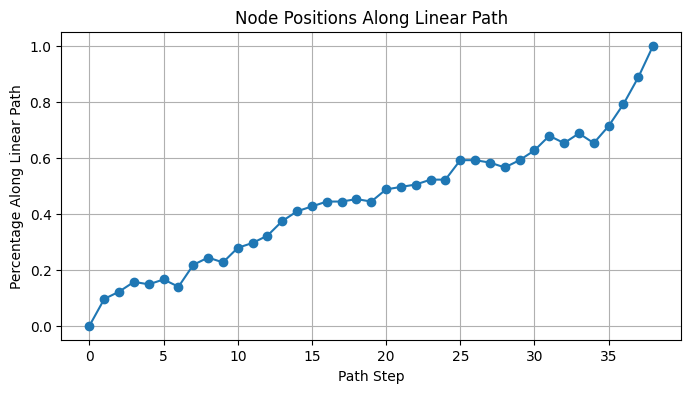

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve the start and end vectors
vec_start = vectors_np[mapping[i]]
vec_end = vectors_np[mapping[j]]

# Compute the direction vector of the linear path
direction = vec_end - vec_start
direction_norm_sq = np.dot(direction, direction)

# Compute the percentage position along the linear path for each node in the path
percentages = []
for node_idx in path:
    vec = vectors_np[mapping[node_idx]]
    projection_length = np.dot(vec - vec_start, direction) / direction_norm_sq
    # Clamp the projection length to the [0, 1] interval
    projection_length = max(0.0, min(1.0, projection_length))
    percentages.append(projection_length)

# Display the percentage positions
# for idx, perc in enumerate(percentages):
#     print(f"Node {idx} (original index {mapping[path[idx]]}): {perc * 100:.2f}% along the linear path")

# Optional: Visualize the distribution of percentages
plt.figure(figsize=(8, 4))
plt.plot(percentages, marker='o')
plt.title("Node Positions Along Linear Path")
plt.xlabel("Path Step")
plt.ylabel("Percentage Along Linear Path")
plt.grid(True)
plt.show()


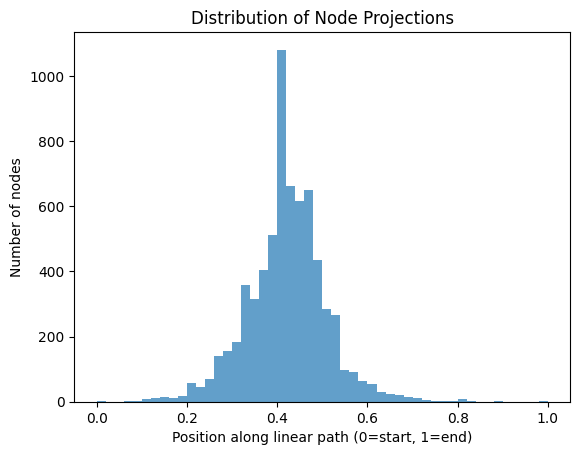

Projected nodes: 6726 / 6726 (100.00%)
Ignored nodes: 0 / 6726 (0.00%)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve the start and end vectors
vec_start = vectors_np[mapping[i]]
vec_end = vectors_np[mapping[j]]

# Compute the direction vector and its squared norm
direction = vec_end - vec_start
direction_norm_sq = np.dot(direction, direction)

# Compute the scalar projection for each node
projections = np.dot(vectors_np - vec_start, direction) / direction_norm_sq

# Optional: Clamp projections to [0, 1] if desired
projections_clamped = np.clip(projections, 0.0, 1.0)

# Example: Plot histogram of projections
plt.hist(projections_clamped, bins=50, alpha=0.7)
plt.xlabel('Position along linear path (0=start, 1=end)')
plt.ylabel('Number of nodes')
plt.title('Distribution of Node Projections')
plt.show()

projected_count = len(projections_clamped)
total_count = vectors_np.shape[0]
ignored_count = total_count - projected_count

print(f"Projected nodes: {projected_count} / {total_count} "
      f"({100 * projected_count / total_count:.2f}%)")
print(f"Ignored nodes: {ignored_count} / {total_count} "
      f"({100 * ignored_count / total_count:.2f}%)")



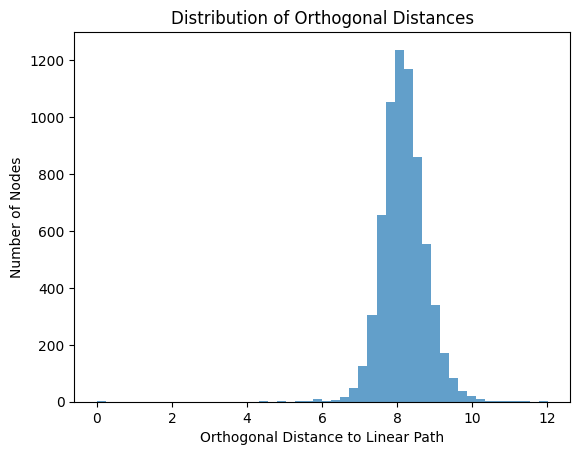

Mean orthogonal distance: 8.1801
Max orthogonal distance: 12.0185
Median orthogonal distance: 8.1609


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve the start and end vectors
vec_start = vectors_np[mapping[i]]
vec_end = vectors_np[mapping[j]]

# Compute the direction vector and its squared norm
direction = vec_end - vec_start
direction_norm_sq = np.dot(direction, direction)

# Compute the scalar projection for each node
projections = np.dot(vectors_np - vec_start, direction) / direction_norm_sq

# Compute the projected points on the line
projected_points = vec_start + np.outer(projections, direction)

# Compute the orthogonal components
orthogonal_components = vectors_np - projected_points

# Compute the magnitudes of the orthogonal components
orthogonal_distances = np.linalg.norm(orthogonal_components, axis=1)

# Plot histogram of orthogonal distances
plt.hist(orthogonal_distances, bins=50, alpha=0.7)
plt.xlabel('Orthogonal Distance to Linear Path')
plt.ylabel('Number of Nodes')
plt.title('Distribution of Orthogonal Distances')
plt.show()

# Print statistics
mean_distance = np.mean(orthogonal_distances)
max_distance = np.max(orthogonal_distances)
print(f"Mean orthogonal distance: {mean_distance:.4f}")
print(f"Max orthogonal distance: {max_distance:.4f}")
print(f"Median orthogonal distance: {np.median(orthogonal_distances):.4f}")


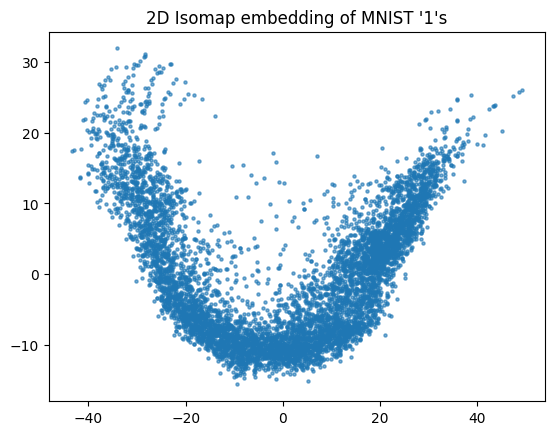

'\nat a high level seems to build knn, compute shortest path matrix between every pair of nodes then do some sort\nof dimension reduction based on a similar idea to spectral embedding. take eigenvector of distance matrix and\ntry to maintain similarity/disimilarity between nodes\n'

In [11]:
from sklearn.manifold import Isomap

# X = your N×784 array of unique_vectors
iso = Isomap(n_neighbors=5, n_components=2)
embedding_2d = iso.fit_transform(vectors_np)  # shape (N, 2)

# Plot
plt.scatter(embedding_2d[:,0], embedding_2d[:,1], s=5, alpha=0.6)
plt.title("2D Isomap embedding of MNIST '1's")
plt.show()

'''
at a high level seems to build knn, compute shortest path matrix between every pair of nodes then do some sort
of dimension reduction based on a similar idea to spectral embedding. take eigenvector of distance matrix and
try to maintain similarity/disimilarity between nodes
'''

In [12]:
# Find peaks (higher than all neighbors)
peak_nodes = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v) and all(
        orthogonal_distances[v] > orthogonal_distances[nb]
        for nb in g_thresh.neighbors(v)
    )
]

# Find valleys (lower than all neighbors)
valley_nodes = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v) and all(
        orthogonal_distances[v] < orthogonal_distances[nb]
        for nb in g_thresh.neighbors(v)
    )
]

total = g_thresh.vcount()
print(f"Peak nodes:   {len(peak_nodes)} / {total}  ({100*len(peak_nodes)/total:.2f}%)")
print(f"Valley nodes: {len(valley_nodes)} / {total}  ({100*len(valley_nodes)/total:.2f}%)")

print("Peak indices:  ", peak_nodes)
print("Valley indices:", valley_nodes)


Peak nodes:   871 / 6726  (12.95%)
Valley nodes: 836 / 6726  (12.43%)
Peak indices:   [5, 15, 24, 30, 34, 39, 40, 54, 67, 73, 89, 93, 98, 102, 103, 106, 109, 110, 128, 135, 154, 156, 198, 204, 212, 218, 222, 229, 268, 276, 281, 308, 334, 337, 348, 351, 352, 367, 370, 374, 380, 403, 405, 434, 438, 443, 449, 452, 454, 457, 468, 491, 502, 505, 507, 514, 529, 544, 557, 566, 568, 569, 571, 572, 573, 585, 586, 695, 698, 703, 728, 730, 748, 763, 772, 773, 774, 783, 788, 789, 792, 799, 800, 803, 806, 809, 817, 820, 821, 826, 831, 832, 837, 838, 843, 855, 858, 860, 861, 866, 868, 870, 873, 934, 957, 978, 1000, 1014, 1039, 1040, 1041, 1058, 1064, 1069, 1071, 1072, 1073, 1080, 1081, 1086, 1093, 1104, 1106, 1109, 1112, 1127, 1131, 1133, 1134, 1136, 1137, 1145, 1147, 1163, 1172, 1176, 1182, 1185, 1187, 1195, 1207, 1213, 1214, 1222, 1236, 1282, 1315, 1317, 1358, 1366, 1368, 1369, 1376, 1381, 1382, 1384, 1387, 1390, 1396, 1409, 1410, 1417, 1425, 1428, 1433, 1434, 1441, 1447, 1473, 1479, 1480, 1481, 1

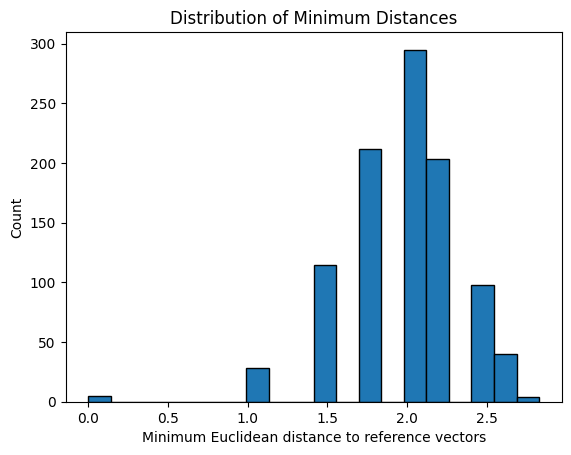

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1000  # number of random 10-dimensional vectors

# Generate random 10-dimensional binary vectors
vectors = np.random.randint(0, 2, size=(N, 10))

# Define the four reference vectors
refs = np.array([
    [0, 0] + [0]*8,
    [0, 1] + [0]*8,
    [1, 0] + [0]*8,
    [1, 1] + [0]*8
], dtype=float)

# Compute Euclidean distances to each reference
distances = np.linalg.norm(vectors[:, None, :] - refs[None, :, :], axis=2)

# Find the minimum distance per vector
min_distances = np.min(distances, axis=1)

# Visualize distribution
plt.hist(min_distances, bins=20, edgecolor='k')
plt.xlabel('Minimum Euclidean distance to reference vectors')
plt.ylabel('Count')
plt.title('Distribution of Minimum Distances')
plt.show()


In [14]:
import numpy as np

# — Assumes you already have:
#    unique_vectors  # torch.Tensor or numpy array shape (N, D)
#    g_thresh        # your igraph k-NN graph on these N nodes


# 1) Build the four reference points defining the 2D “ground” in D dimensions
N, D = vectors_np.shape
refs = np.zeros((4, D))
# [0,0,0,...]
# [0,1,0,...]
refs[1, 1] = 1
# [1,0,0,...]
refs[2, 0] = 1
# [1,1,0,...]
refs[3, 0] = 1
refs[3, 1] = 1

# 2) Compute Euclidean distances from each node to each reference
distances = np.linalg.norm(vectors_np[:, None, :] - refs[None, :, :], axis=2)  # shape (N, 4)

# 3) Elevation = minimum distance to the 4 reference points
elevation = np.min(distances, axis=1)  # shape (N,)

# 4) Identify peaks (higher than all neighbors) and troughs (lower than all neighbors)
peak_nodes = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v) and all(elevation[v] > elevation[n] for n in g_thresh.neighbors(v))
]
trough_nodes = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v) and all(elevation[v] < elevation[n] for n in g_thresh.neighbors(v))
]

# 5) Report counts and percentages
total = g_thresh.vcount()
print(f"Peaks (higher than all neighbors):   {len(peak_nodes)} / {total}  ({100 * len(peak_nodes) / total:.2f}%)")
print(f"Troughs (lower than all neighbors):  {len(trough_nodes)} / {total}  ({100 * len(trough_nodes) / total:.2f}%)")

# 6) Inspect indices
print("Peak indices:  ", peak_nodes)
print("Trough indices:", trough_nodes)


Peaks (higher than all neighbors):   603 / 6726  (8.97%)
Troughs (lower than all neighbors):  583 / 6726  (8.67%)
Peak indices:   [5, 10, 16, 24, 27, 30, 34, 54, 67, 73, 93, 103, 109, 154, 172, 202, 212, 213, 225, 226, 229, 276, 300, 314, 337, 347, 348, 351, 365, 375, 443, 449, 454, 470, 494, 505, 514, 521, 524, 529, 548, 569, 572, 573, 576, 582, 585, 698, 728, 730, 748, 758, 772, 774, 789, 799, 800, 803, 809, 817, 831, 838, 843, 855, 861, 868, 870, 957, 978, 985, 1000, 1002, 1040, 1062, 1071, 1080, 1081, 1093, 1109, 1130, 1133, 1134, 1136, 1137, 1155, 1159, 1163, 1180, 1187, 1207, 1210, 1213, 1214, 1282, 1311, 1315, 1368, 1376, 1381, 1382, 1387, 1391, 1396, 1409, 1410, 1412, 1419, 1425, 1428, 1441, 1454, 1473, 1479, 1486, 1502, 1504, 1525, 1534, 1538, 1543, 1547, 1552, 1553, 1561, 1568, 1571, 1575, 1577, 1578, 1579, 1583, 1584, 1586, 1672, 1684, 1711, 1720, 1721, 1722, 1756, 1757, 1770, 1778, 1783, 1794, 1796, 1798, 1803, 1804, 1816, 1825, 1830, 1831, 1854, 1867, 1875, 1876, 1878, 188

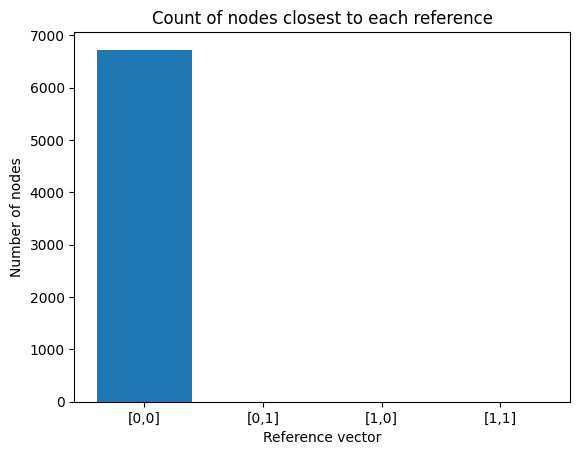

'\nall are closest to 0,0 because the first 2 pixels of mnist binarized 1s are always 0s. theyre background space,\nthey never vary.\n'

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Determine for each node which reference it is closest to
closest_ref = np.argmin(distances, axis=1)

# 2) Count how many nodes are closest to each of the 4 refs
counts = np.bincount(closest_ref, minlength=4)

# 3) Plot
labels = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
plt.bar(labels, counts)
plt.xlabel('Reference vector')
plt.ylabel('Number of nodes')
plt.title('Count of nodes closest to each reference')
plt.show()

'''
all are closest to 0,0 because the first 2 pixels of mnist binarized 1s are always 0s. theyre background space,
they never vary.
'''

In [16]:
import numpy as np

# — Assumes you have in scope:
#    vectors_np    # numpy array of shape (N, D)
#    g_thresh      # igraph Graph built over these N nodes

# 1) Memory‑efficient elevation:
#    distance to the nearest one‑hot basis vector e_i is sqrt(||v||^2 + 1 - 2*v_i)
norm_sq    = np.sum(vectors_np**2, axis=1)        # shape: (N,)
max_comp   = np.max(vectors_np, axis=1)           # shape: (N,)
elevation  = np.sqrt(norm_sq + 1 - 2 * max_comp)  # shape: (N,)

# 2) Identify peaks and troughs relative to graph neighbors
peaks = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v) and all(elevation[v] > elevation[n] for n in g_thresh.neighbors(v))
]
troughs = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v) and all(elevation[v] < elevation[n] for n in g_thresh.neighbors(v))
]

# 3) Report counts and indices
total = g_thresh.vcount()
print(f"Peaks:   {len(peaks)} / {total} nodes ({100 * len(peaks) / total:.2f}%)")
print(f"Troughs: {len(troughs)} / {total} nodes ({100 * len(troughs) / total:.2f}%)")
print("Peak indices:  ", peaks)
print("Trough indices:", troughs)


Peaks:   603 / 6726 nodes (8.97%)
Troughs: 583 / 6726 nodes (8.67%)
Peak indices:   [5, 10, 16, 24, 27, 30, 34, 54, 67, 73, 93, 103, 109, 154, 172, 202, 212, 213, 225, 226, 229, 276, 300, 314, 337, 347, 348, 351, 365, 375, 443, 449, 454, 470, 494, 505, 514, 521, 524, 529, 548, 569, 572, 573, 576, 582, 585, 698, 728, 730, 748, 758, 772, 774, 789, 799, 800, 803, 809, 817, 831, 838, 843, 855, 861, 868, 870, 957, 978, 985, 1000, 1002, 1040, 1062, 1071, 1080, 1081, 1093, 1109, 1130, 1133, 1134, 1136, 1137, 1155, 1159, 1163, 1180, 1187, 1207, 1210, 1213, 1214, 1282, 1311, 1315, 1368, 1376, 1381, 1382, 1387, 1391, 1396, 1409, 1410, 1412, 1419, 1425, 1428, 1441, 1454, 1473, 1479, 1486, 1502, 1504, 1525, 1534, 1538, 1543, 1547, 1552, 1553, 1561, 1568, 1571, 1575, 1577, 1578, 1579, 1583, 1584, 1586, 1672, 1684, 1711, 1720, 1721, 1722, 1756, 1757, 1770, 1778, 1783, 1794, 1796, 1798, 1803, 1804, 1816, 1825, 1830, 1831, 1854, 1867, 1875, 1876, 1878, 1880, 1888, 1894, 1895, 1901, 1919, 1928, 1951, 1

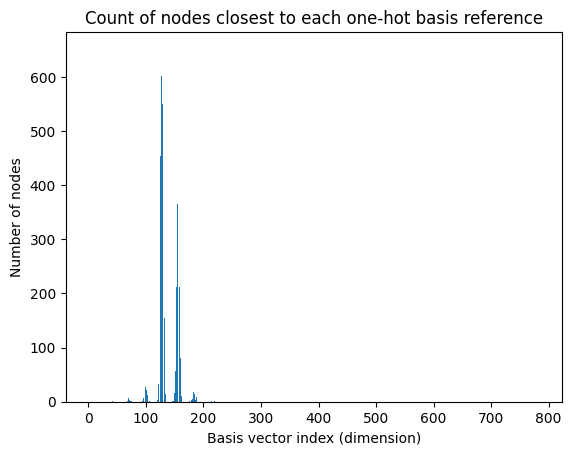

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes `vectors_np` (shape (N, D)) is already in scope

# 1) Find for each node the basis index with minimal distance (i.e., argmax of its components)
closest_basis = np.argmax(vectors_np, axis=1)  # shape (N,)

# 2) Count how many nodes map to each basis index
D = vectors_np.shape[1]
counts = np.bincount(closest_basis, minlength=D)

# 3) Plot the distribution
plt.bar(np.arange(D), counts)
plt.xlabel('Basis vector index (dimension)')
plt.ylabel('Number of nodes')
plt.title('Count of nodes closest to each one-hot basis reference')
plt.show()


In [18]:
from sklearn.decomposition import PCA
import numpy as np

# 1) Fit PCA and extract the first two components
pca = PCA(n_components=2)
pca.fit(vectors_np)
u1, u2 = pca.components_  # each is length‑D

# 2) Compute projection of each v onto the plane
proj_on_u1 = vectors_np.dot(u1)[:,None] * u1[None,:]   # shape (N, D)
proj_on_u2 = vectors_np.dot(u2)[:,None] * u2[None,:]
plane_proj = proj_on_u1 + proj_on_u2                   # shape (N, D)

# 3) Residual = v — its projection
residuals = vectors_np - plane_proj                     # shape (N, D)

# 4) Elevation = norm of that residual
elevation = np.linalg.norm(residuals, axis=1)           # shape (N,)

# 5) Recompute peaks/troughs exactly as before
peaks = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v)
       and all(elevation[v] > elevation[n] for n in g_thresh.neighbors(v))
]
troughs = [
    v for v in range(g_thresh.vcount())
    if g_thresh.neighbors(v)
       and all(elevation[v] < elevation[n] for n in g_thresh.neighbors(v))
]

# 3) Report counts and indices
total = g_thresh.vcount()
print(f"Peaks:   {len(peaks)} / {total} nodes ({100 * len(peaks) / total:.2f}%)")
print(f"Troughs: {len(troughs)} / {total} nodes ({100 * len(troughs) / total:.2f}%)")
print("Peak indices:  ", peaks)
print("Trough indices:", troughs)

Peaks:   853 / 6726 nodes (12.68%)
Troughs: 678 / 6726 nodes (10.08%)
Peak indices:   [2, 5, 10, 11, 16, 24, 26, 27, 30, 34, 37, 38, 39, 43, 45, 50, 54, 55, 64, 67, 73, 75, 80, 86, 93, 98, 103, 104, 106, 107, 109, 110, 145, 148, 154, 155, 172, 198, 212, 213, 226, 229, 231, 249, 276, 300, 314, 320, 322, 337, 342, 348, 351, 362, 365, 370, 380, 389, 403, 405, 425, 436, 443, 449, 454, 460, 470, 500, 505, 509, 514, 521, 524, 539, 553, 569, 572, 573, 582, 585, 597, 626, 631, 644, 661, 673, 675, 682, 686, 698, 705, 710, 746, 748, 755, 758, 763, 765, 772, 774, 788, 789, 792, 799, 800, 803, 806, 809, 817, 820, 834, 838, 843, 855, 861, 866, 868, 870, 901, 903, 914, 928, 932, 957, 978, 983, 984, 985, 998, 1000, 1002, 1007, 1015, 1040, 1062, 1066, 1081, 1093, 1102, 1104, 1105, 1109, 1115, 1118, 1125, 1130, 1133, 1134, 1136, 1137, 1147, 1155, 1159, 1180, 1187, 1206, 1207, 1210, 1213, 1214, 1236, 1239, 1251, 1282, 1366, 1368, 1376, 1381, 1382, 1387, 1396, 1409, 1410, 1412, 1417, 1419, 1423, 1428, 14

In [19]:
import numpy as np

def random_plane(D):
    # Sample a random 2D subspace in R^D
    X = np.random.randn(D, 2)
    Q, _ = np.linalg.qr(X)   # Q[:,0], Q[:,1] are orthonormal
    return Q[:,0], Q[:,1]

def evaluate_plane(u, v, vectors_np, neighbors):
    # Precompute projections
    p1 = vectors_np.dot(u)      # shape (N,)
    p2 = vectors_np.dot(v)
    # Compute residual norms: ||x||^2 - p1^2 - p2^2
    norm_sq = np.sum(vectors_np**2, axis=1)
    elev   = np.sqrt(np.clip(norm_sq - p1**2 - p2**2, 0, None))

    N = len(elev)
    peaks = troughs = 0
    for i in range(N):
        nbrs = neighbors[i]
        if not nbrs:
            continue
        e_i = elev[i]
        # compare to neighbors
        if all(e_i > elev[j] for j in nbrs):
            peaks += 1
        if all(e_i < elev[j] for j in nbrs):
            troughs += 1
    return peaks + troughs

# Pre‑extract neighbor lists from your igraph g_thresh:
neighbors = [g_thresh.neighbors(v) for v in range(g_thresh.vcount())]

best_score = -1
best_plane = None

# Random search
for trial in range(200):            # try 200 random planes
    u, v = random_plane(D)
    score = evaluate_plane(u, v, vectors_np, neighbors)
    if score > best_score:
        best_score = score
        best_plane = (u, v)

print("Best total peaks+troughs:", best_score)
# best_plane holds your optimal (u, v)


Best total peaks+troughs: 1441


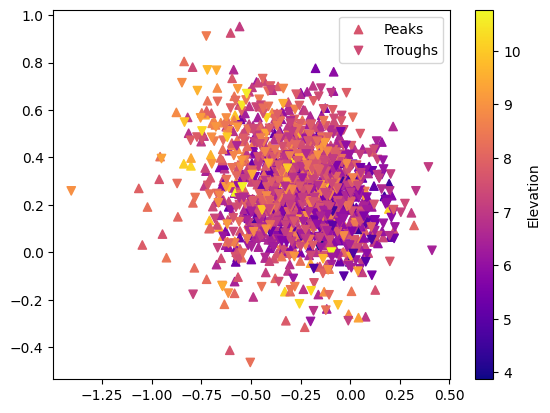

In [20]:
# 1) Unpack your best plane
u, v = best_plane  # from your random search

# 2) Compute each point’s orthogonal residual (elevation) off that plane
p1     = vectors_np.dot(u)                   # projection onto u, shape (N,)
p2     = vectors_np.dot(v)                   # projection onto v, shape (N,)
norm_sq = np.sum(vectors_np**2, axis=1)      # ‖x‖² for each vector
elevation = np.sqrt(np.clip(norm_sq - p1**2 - p2**2, 0, None))

# 3) Re‑identify peaks and troughs on this elevation
neighbors = [g_thresh.neighbors(i) for i in range(g_thresh.vcount())]

peaks   = [i for i in range(vectors_np.shape[0])
           if neighbors[i] and all(elevation[i] > elevation[j] for j in neighbors[i])]

troughs = [i for i in range(vectors_np.shape[0])
           if neighbors[i] and all(elevation[i] < elevation[j] for j in neighbors[i])]

# 4) Now you can plot coords or inspect those indices
coords = np.vstack([vectors_np.dot(u), vectors_np.dot(v)]).T
plt.scatter(coords[peaks,0], coords[peaks,1], c=elevation[peaks], cmap='plasma', marker='^', label='Peaks')
plt.scatter(coords[troughs,0], coords[troughs,1], c=elevation[troughs], cmap='plasma', marker='v', label='Troughs')
plt.colorbar(label='Elevation')
plt.legend(); plt.show()


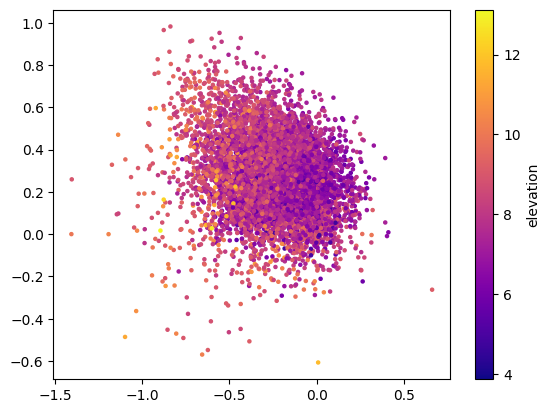

In [21]:
# in Colab, after you have u, v, vectors_np:
coords = np.vstack([
    vectors_np.dot(u),   # x‐axis
    vectors_np.dot(v)    # y‐axis
]).T  # shape (N,2)

plt.scatter(coords[:,0], coords[:,1], c=elevation, cmap='plasma', s=5)
plt.colorbar(label='elevation')
plt.show()


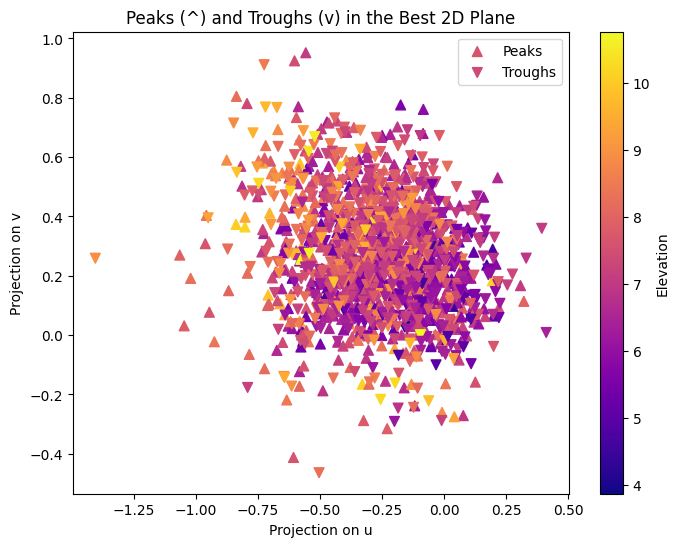

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes u, v, vectors_np, elevation, peaks, troughs are already defined

# Compute 2D coordinates in the (u, v) plane
coords = np.vstack([
    vectors_np.dot(u),   # x-axis
    vectors_np.dot(v)    # y-axis
]).T  # shape (N,2)

# Plot only peaks and troughs
plt.figure(figsize=(8, 6))
plt.scatter(coords[peaks, 0], coords[peaks, 1],
            c=elevation[peaks], cmap='plasma',
            marker='^', s=50, label='Peaks')
plt.scatter(coords[troughs, 0], coords[troughs, 1],
            c=elevation[troughs], cmap='plasma',
            marker='v', s=50, label='Troughs')
plt.colorbar(label='Elevation')
plt.legend()
plt.xlabel('Projection on u')
plt.ylabel('Projection on v')
plt.title('Peaks (^) and Troughs (v) in the Best 2D Plane')
plt.show()


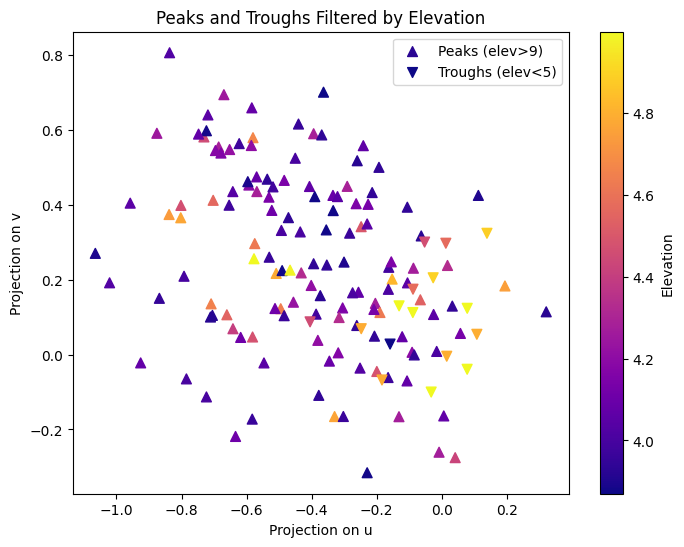

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes u, v, vectors_np, elevation, peaks, troughs are already defined

# Recompute 2D coordinates on the (u, v) plane
coords = np.vstack([
    vectors_np.dot(u),   # x-axis
    vectors_np.dot(v)    # y-axis
]).T  # shape (N,2)

# Filter peaks with elevation > 9 and troughs with elevation < 5
peaks_high = [v for v in peaks if elevation[v] > 9]
troughs_low = [v for v in troughs if elevation[v] < 5]

plt.figure(figsize=(8, 6))
if peaks_high:
    plt.scatter(coords[peaks_high, 0], coords[peaks_high, 1],
                c=elevation[peaks_high], cmap='plasma',
                marker='^', s=50, label='Peaks (elev>9)')
if troughs_low:
    plt.scatter(coords[troughs_low, 0], coords[troughs_low, 1],
                c=elevation[troughs_low], cmap='plasma',
                marker='v', s=50, label='Troughs (elev<5)')
plt.colorbar(label='Elevation')
plt.legend()
plt.xlabel('Projection on u')
plt.ylabel('Projection on v')
plt.title('Peaks and Troughs Filtered by Elevation')
plt.show()


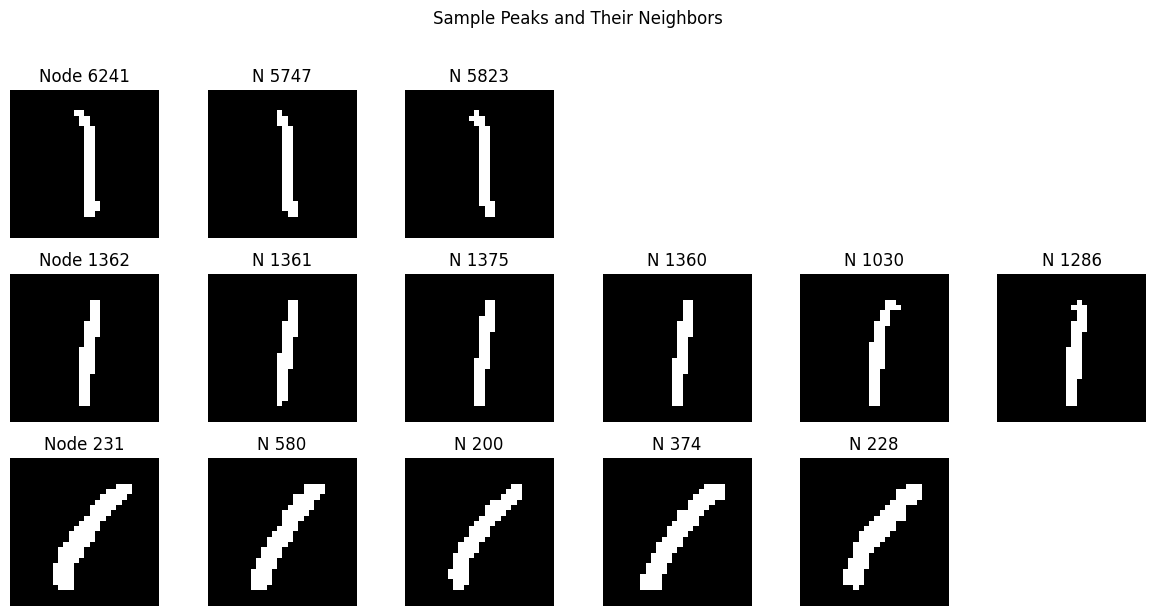

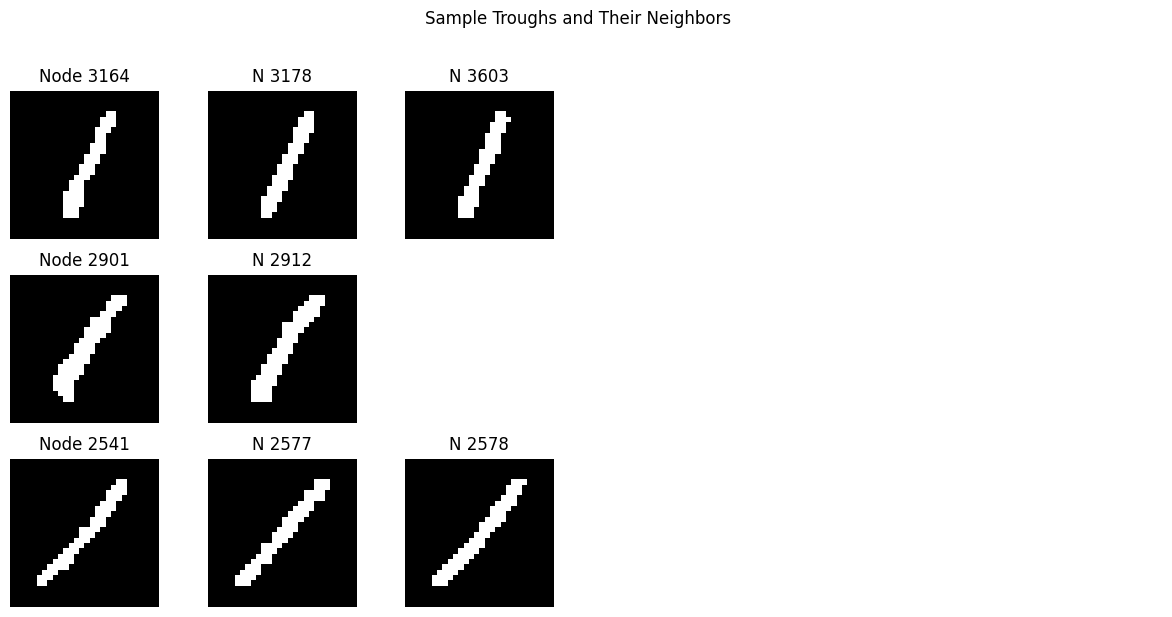

In [24]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_samples = 3
max_neighbors = 5
img_shape = (28, 28)
random.seed(42)

def plot_samples(sample_nodes, title):
    fig, axes = plt.subplots(num_samples, max_neighbors + 1,
                             figsize=(2 * (max_neighbors + 1), 2 * num_samples))
    fig.suptitle(title, y=1.02)
    for i, v in enumerate(sample_nodes):
        # Plot the central peak/trough node
        ax = axes[i, 0] if num_samples > 1 else axes[0]
        ax.imshow(vectors_np[v].reshape(img_shape), cmap='gray')
        ax.set_title(f"Node {v}")
        ax.axis('off')

        # Sample neighbors
        nbrs = g_thresh.neighbors(v)
        sampled_nbrs = random.sample(nbrs, min(len(nbrs), max_neighbors))
        for j in range(max_neighbors):
            ax = axes[i, j + 1] if num_samples > 1 else axes[j + 1]
            if j < len(sampled_nbrs):
                u = sampled_nbrs[j]
                ax.imshow(vectors_np[u].reshape(img_shape), cmap='gray')
                ax.set_title(f"N {u}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

# Randomly sample peaks and troughs
sample_peaks = random.sample(peaks, min(len(peaks), num_samples))
sample_troughs = random.sample(troughs, min(len(troughs), num_samples))

# Plot
plot_samples(sample_peaks, "Sample Peaks and Their Neighbors")
plot_samples(sample_troughs, "Sample Troughs and Their Neighbors")


In [25]:
import numpy as np

# — Assumes you’ve already computed:
#    elevation    # numpy array shape (N,)
#    peaks        # list of peak node indices
#    troughs      # list of trough node indices
#    g_thresh     # your igraph k-NN graph

# 1) Compute peak differences
peak_diffs = []
for v in peaks:
    nbrs = g_thresh.neighbors(v)
    med = np.median(elevation[nbrs])
    diff = elevation[v] - med
    peak_diffs.append((v, diff))

# sort peaks by descending diff
peak_diffs.sort(key=lambda x: x[1], reverse=True)

# 2) Compute trough differences
trough_diffs = []
for v in troughs:
    nbrs = g_thresh.neighbors(v)
    med = np.median(elevation[nbrs])
    diff = med - elevation[v]
    trough_diffs.append((v, diff))

# sort troughs by descending diff
trough_diffs.sort(key=lambda x: x[1], reverse=True)

# 3) Display top 10 of each
print("Top 10 Peaks by elevation gap:")
for v, d in peak_diffs[:10]:
    print(f"  Node {v}: Δ = {d:.4f}")

print("\nTop 10 Troughs by elevation gap:")
for v, d in trough_diffs[:10]:
    print(f"  Node {v}: Δ = {d:.4f}")


Top 10 Peaks by elevation gap:
  Node 6638: Δ = 1.2551
  Node 2583: Δ = 1.2109
  Node 1109: Δ = 1.1283
  Node 1368: Δ = 1.0980
  Node 154: Δ = 1.0723
  Node 6537: Δ = 1.0624
  Node 2052: Δ = 1.0148
  Node 6601: Δ = 0.9862
  Node 1479: Δ = 0.9783
  Node 585: Δ = 0.9663

Top 10 Troughs by elevation gap:
  Node 4512: Δ = 1.4817
  Node 6634: Δ = 1.4470
  Node 6663: Δ = 1.2551
  Node 111: Δ = 1.2207
  Node 5709: Δ = 1.2011
  Node 3315: Δ = 1.0533
  Node 2211: Δ = 1.0521
  Node 6165: Δ = 1.0379
  Node 130: Δ = 1.0126
  Node 2666: Δ = 0.9788


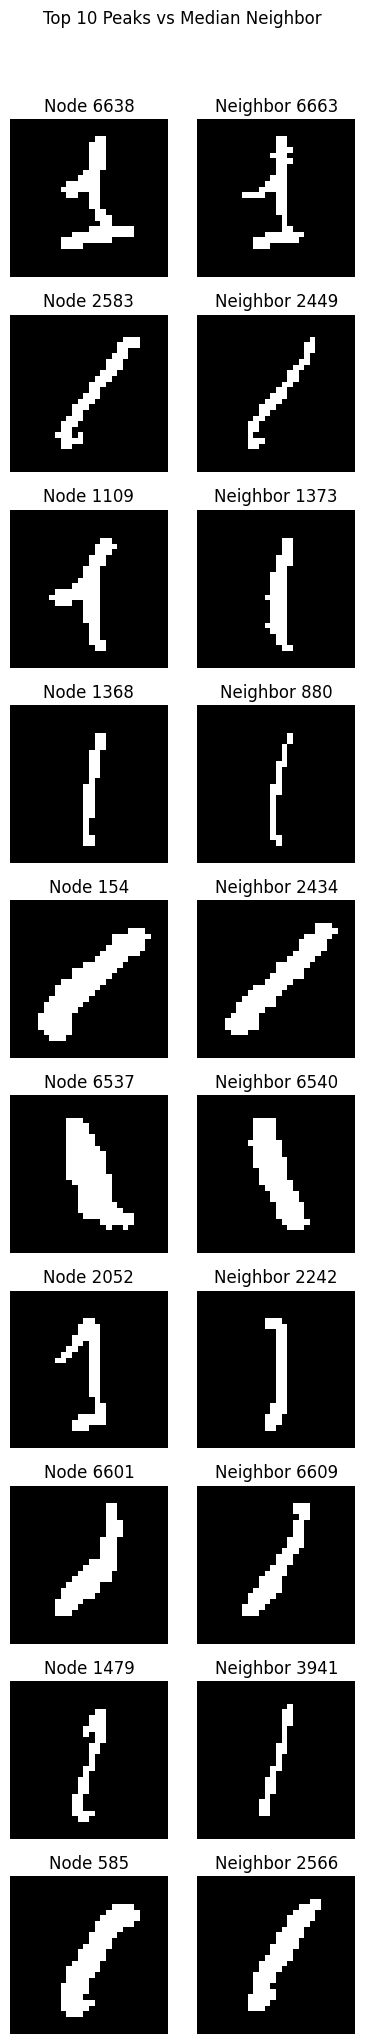

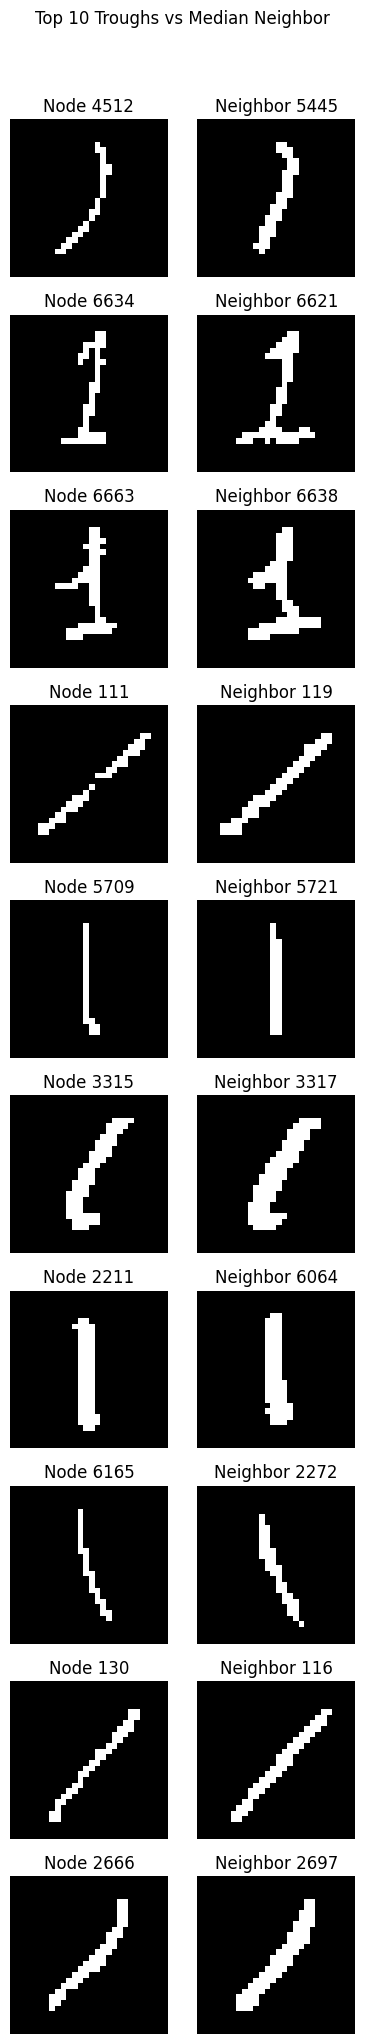

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# — Assumes these are in scope:
#    vectors_np    # numpy array shape (N, 784)
#    g_thresh      # igraph Graph
#    elevation     # numpy array of shape (N,)
#    peak_diffs    # list of (node, diff) sorted descending
#    trough_diffs  # list of (node, diff) sorted descending

# Number to display
n_display = min(10, len(peak_diffs), len(trough_diffs))

# Extract top nodes
top_peaks = [v for v, _ in peak_diffs[:n_display]]
top_troughs = [v for v, _ in trough_diffs[:n_display]]

# Helper to find median neighbor index
def median_neighbor(v):
    nbrs = g_thresh.neighbors(v)
    neigh_elev = elevation[nbrs]
    med = np.median(neigh_elev)
    idx = np.argmin(np.abs(neigh_elev - med))
    return nbrs[idx]

# Plotting function
def plot_comparison(nodes, title):
    fig, axes = plt.subplots(len(nodes), 2, figsize=(4, 2 * len(nodes)))
    fig.suptitle(title, y=1.02)
    for i, v in enumerate(nodes):
        # Plot the node
        ax = axes[i, 0] if len(nodes) > 1 else axes[0]
        ax.imshow(vectors_np[v].reshape(28, 28), cmap='gray')
        ax.set_title(f"Node {v}")
        ax.axis('off')
        # Plot median neighbor
        m = median_neighbor(v)
        ax = axes[i, 1] if len(nodes) > 1 else axes[1]
        ax.imshow(vectors_np[m].reshape(28, 28), cmap='gray')
        ax.set_title(f"Neighbor {m}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Show top peaks
plot_comparison(top_peaks, "Top 10 Peaks vs Median Neighbor")

# Show top troughs
plot_comparison(top_troughs, "Top 10 Troughs vs Median Neighbor")


In [27]:
import numpy as np

# — Assumes you already have:
#    vectors_np  # numpy array shape (N, D)
#    D           # dimensionality of vectors (D = vectors_np.shape[1])

def random_plane(D):
    """Sample a random 2D subspace in R^D."""
    X = np.random.randn(D, 2)
    Q, _ = np.linalg.qr(X)
    return Q[:, 0], Q[:, 1]

def evaluate_plane_dev(u, v, vectors_np):
    """
    Compute the 'elevation' residuals of each vector off the (u,v) plane,
    then return the sum of absolute deviations from the median elevation.
    """
    # 1) Projections onto plane axes
    # project each vector onto the 2d plane
    p1 = vectors_np.dot(u)         # shape (N,)
    p2 = vectors_np.dot(v)

    # 2) Residual norms (elevation)
    # norm_sq = distance from origin to each vector
    norm_sq = np.sum(vectors_np**2, axis=1)
    # norm_sq - (p1^2 + p2^2) = distance from origin to vector - projected point on plane = how far away from the plane the vector is = elevation
    elev = np.sqrt(np.clip(norm_sq - p1**2 - p2**2, 0, None))

    # 3) Sum of absolute deviations from median
    med = np.median(elev)
    return np.sum(np.abs(elev - med))

# 4) Random search over planes
best_score = -np.inf
best_plane_dev = None

for trial in range(200):  # adjust number of trials as needed
    u, v = random_plane(D)
    score = evaluate_plane_dev(u, v, vectors_np)
    if score > best_score:
        best_score = score
        best_plane_dev = (u, v)

print("Best total absolute deviation from median elevation:", best_score)



Best total absolute deviation from median elevation: 5984.580720982615


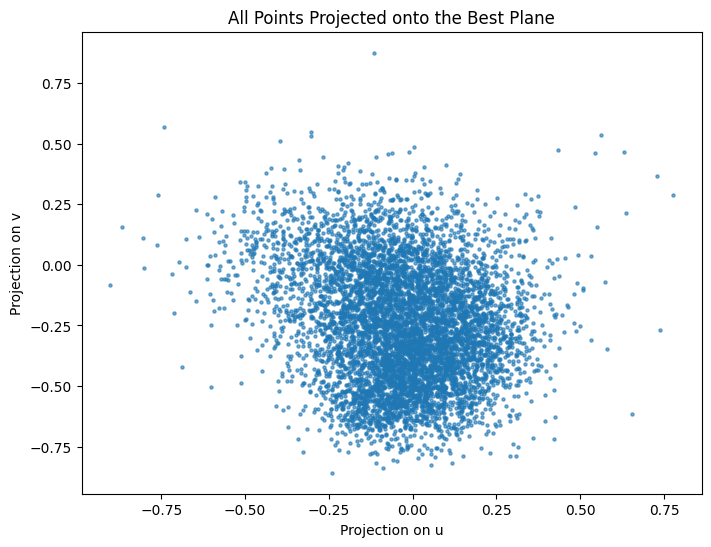

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you have in scope:
#    vectors_np   # numpy array of shape (N, D)
#    best_plane   # tuple (u, v) from your search

# 1) Unpack the best plane vectors
u, v = best_plane_dev

# 2) Compute 2D coordinates by projecting onto u and v
coords = np.vstack([
    vectors_np.dot(u),   # x-axis
    vectors_np.dot(v)    # y-axis
]).T  # shape (N, 2)

# 3) Scatter‐plot all projected points
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.6)
plt.xlabel('Projection on u')
plt.ylabel('Projection on v')
plt.title('All Points Projected onto the Best Plane')
plt.show()


Unique rounded positions: 6632 / 6726 (98.60%)


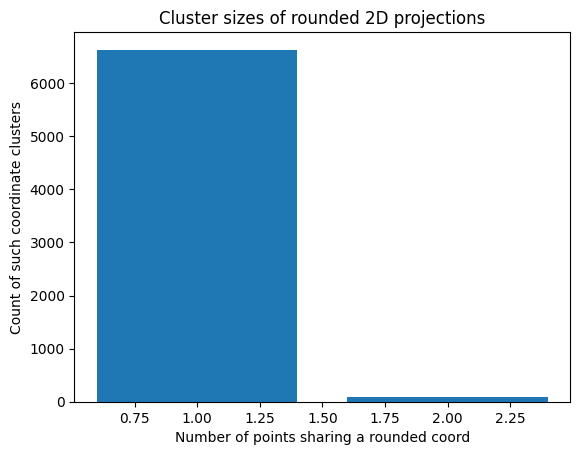

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1) Project onto the best plane
coords = np.vstack([
    vectors_np.dot(u),
    vectors_np.dot(v)
]).T  # shape (N, 2)

# 2) Round coordinates to group 'roughly' equal points
decimals = 3  # adjust rounding precision as needed
coords_rounded = np.round(coords, decimals=decimals)

# 3) Count how many times each rounded coordinate appears
coord_tuples = [tuple(row) for row in coords_rounded]
counter = Counter(coord_tuples)

# 4) Determine which points are unique (only one per coordinate)
counts = np.array([counter[pt] for pt in coord_tuples])
unique_mask = counts == 1
unique_count = unique_mask.sum()
total = coords.shape[0]

# 5) Report
print(f"Unique rounded positions: {unique_count} / {total} "
      f"({100 * unique_count / total:.2f}%)")

# 6) Optional: histogram of cluster sizes
size_counts = Counter(counts)
sizes, freqs = zip(*sorted(size_counts.items()))
plt.bar(sizes, freqs)
plt.xlabel('Number of points sharing a rounded coord')
plt.ylabel('Count of such coordinate clusters')
plt.title('Cluster sizes of rounded 2D projections')
plt.show()


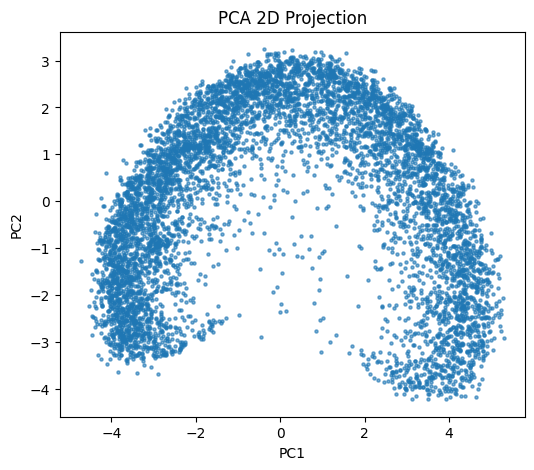

PCA → Unique positions: 6724/6726 (99.97%)


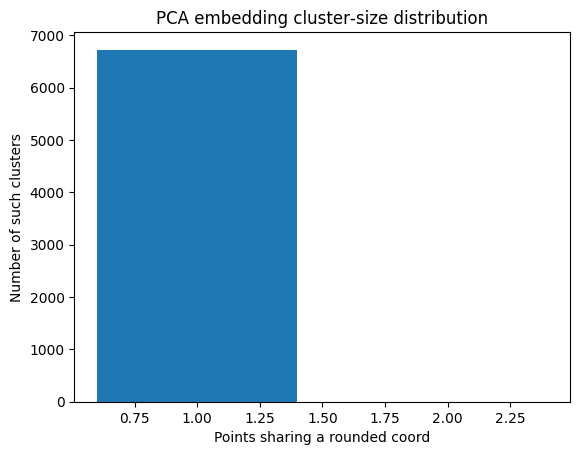

In [30]:
# ┌──────────────────────────────┐
# │ Cell 1: PCA analysis         │
# └──────────────────────────────┘

# (Make sure you’ve already run: !pip install -q umap-learn   if you need UMAP later.)

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1) Compute a 2D PCA embedding
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(vectors_np)   # shape (N,2)

plt.figure(figsize=(6, 5))
plt.scatter(coords_pca[:, 0], coords_pca[:, 1], s=5, alpha=0.6)
plt.title('PCA 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


# 2) Round to group “same” positions
decimals = 3
rounded_pca = np.round(coords_pca, decimals=decimals)
tuples_pca  = [tuple(row) for row in rounded_pca]

# 3) Count occurrences
counts_pca = np.array([Counter(tuples_pca)[t] for t in tuples_pca])
unique_pca = (counts_pca == 1).sum()
total = len(coords_pca)
print(f"PCA → Unique positions: {unique_pca}/{total} ({100*unique_pca/total:.2f}%)")

# 4) Histogram of cluster sizes
size_counts = Counter(counts_pca)
sizes, freqs = zip(*sorted(size_counts.items()))
plt.bar(sizes, freqs)
plt.xlabel('Points sharing a rounded coord')
plt.ylabel('Number of such clusters')
plt.title('PCA embedding cluster‐size distribution')
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


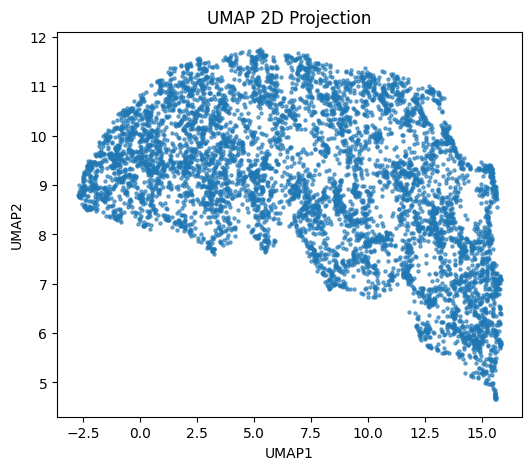

UMAP → Unique positions: 6722/6726 (99.94%)


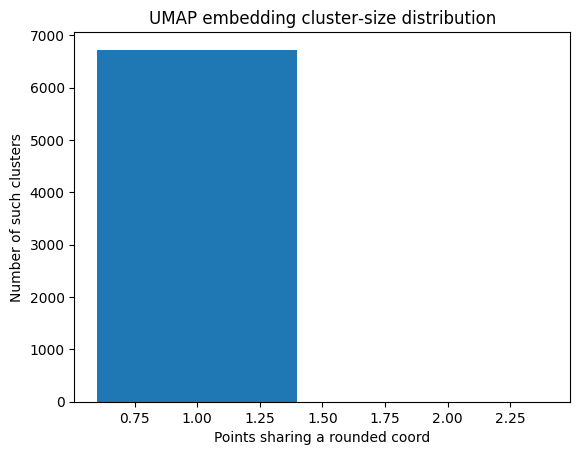

In [31]:
# ┌──────────────────────────────┐
# │ Cell 2: UMAP analysis        │
# └──────────────────────────────┘

import umap
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1) Compute a 2D UMAP embedding
reducer    = umap.UMAP(n_components=2, random_state=42)
coords_umap = reducer.fit_transform(vectors_np)  # shape (N,2)

plt.figure(figsize=(6, 5))
plt.scatter(coords_umap[:, 0], coords_umap[:, 1], s=5, alpha=0.6)
plt.title('UMAP 2D Projection')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

# 2) Round to group “same” positions
decimals   = 3
rounded_umap = np.round(coords_umap, decimals=decimals)
tuples_umap  = [tuple(row) for row in rounded_umap]

# 3) Count occurrences
counts_umap = np.array([Counter(tuples_umap)[t] for t in tuples_umap])
unique_umap = (counts_umap == 1).sum()
total       = len(coords_umap)
print(f"UMAP → Unique positions: {unique_umap}/{total} ({100*unique_umap/total:.2f}%)")

# 4) Histogram of cluster sizes
size_counts = Counter(counts_umap)
sizes, freqs = zip(*sorted(size_counts.items()))
plt.bar(sizes, freqs)
plt.xlabel('Points sharing a rounded coord')
plt.ylabel('Number of such clusters')
plt.title('UMAP embedding cluster‐size distribution')
plt.show()


In [32]:
import numpy as np
from collections import Counter

# — Assumes you already have:
#    vectors_np  # numpy array shape (N, D)
#    D           # dimensionality, D = vectors_np.shape[1]

def random_plane(D):
    """Sample a random 2D subspace in R^D."""
    X = np.random.randn(D, 2)
    Q, _ = np.linalg.qr(X)
    return Q[:, 0], Q[:, 1]

def evaluate_plane_unique(u, v, vectors_np, decimals=3):
    """
    Project each vector onto the (u,v) plane, round coordinates,
    and count how many points are unique in that rounded grid.
    """
    # Project onto u and v
    coords = np.vstack([
        vectors_np.dot(u),   # x-axis
        vectors_np.dot(v)    # y-axis
    ]).T  # shape (N, 2)

    # Round to group 'same' positions
    coords_rounded = np.round(coords, decimals=decimals)
    tuples = [tuple(row) for row in coords_rounded]

    # Count occurrences
    counter = Counter(tuples)
    unique_count = sum(1 for t in tuples if counter[t] == 1)
    return unique_count

# 1) Random search for plane maximizing unique 2D positions
best_unique = -1
best_plane_unique = None
N = vectors_np.shape[0]

for trial in range(200):
    u, v = random_plane(D)
    unique_pts = evaluate_plane_unique(u, v, vectors_np, decimals=3)
    if unique_pts > best_unique:
        best_unique = unique_pts
        best_plane_unique = (u, v)

print(f"Best unique positions: {best_unique} / {N} ({100 * best_unique / N:.2f}%)")



Best unique positions: 6680 / 6726 (99.32%)


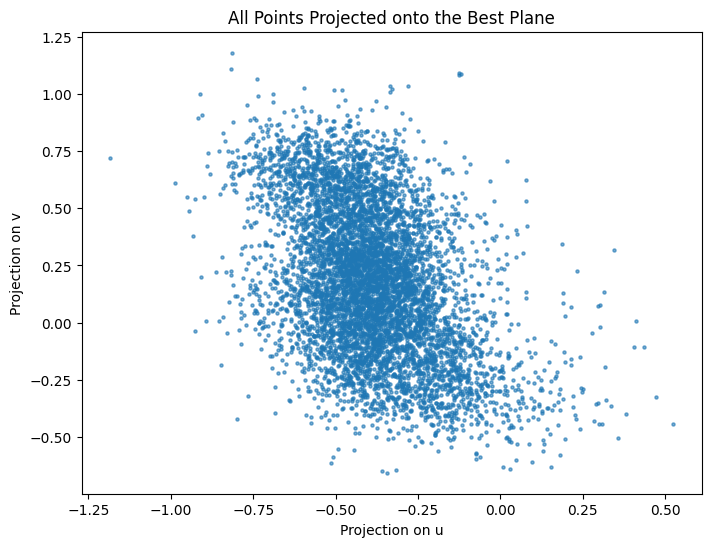

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you have in scope:
#    vectors_np   # numpy array of shape (N, D)
#    best_plane   # tuple (u, v) from your search

# 2) Compute 2D coordinates by projecting onto u and v
coords = np.vstack([
    vectors_np.dot(u),   # x-axis
    vectors_np.dot(v)    # y-axis
]).T  # shape (N, 2)

# 3) Scatter‐plot all projected points
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.6)
plt.xlabel('Projection on u')
plt.ylabel('Projection on v')
plt.title('All Points Projected onto the Best Plane')
plt.show()


Embedding Quality Metrics
-------------------------
Trustworthiness (k=10):       0.8818
Continuity      (k=10):       0.9724
Mean Rel. Rank Error (k=10):  0.0000
Spearman ρ (all pairs):        0.8566
Stress (global distortion):    0.4487



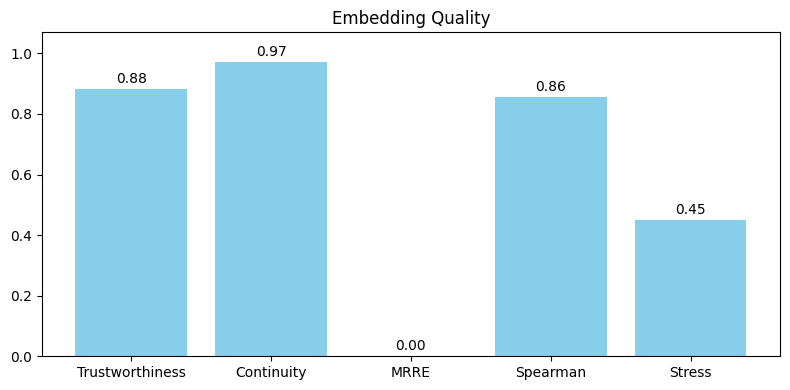

Embedding Quality Metrics
-------------------------
Trustworthiness (k=10):       0.9612
Continuity      (k=10):       0.9830
Mean Rel. Rank Error (k=10):  0.0000
Spearman ρ (all pairs):        0.8406
Stress (global distortion):    0.4022



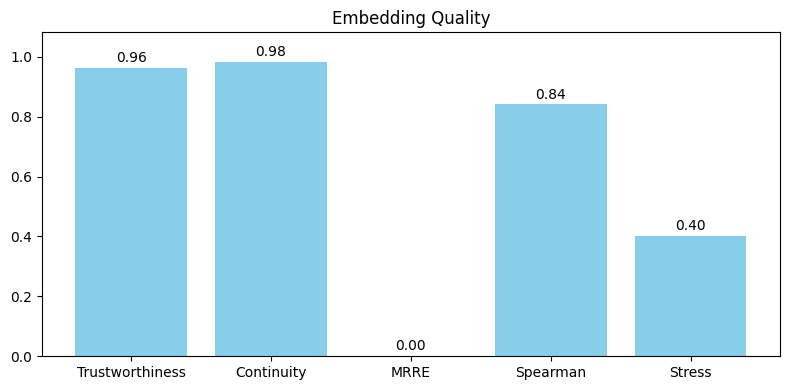

Embedding Quality Metrics
-------------------------
Trustworthiness (k=10):       0.7780
Continuity      (k=10):       0.8845
Mean Rel. Rank Error (k=10):  0.0000
Spearman ρ (all pairs):        0.6520
Stress (global distortion):    0.9388



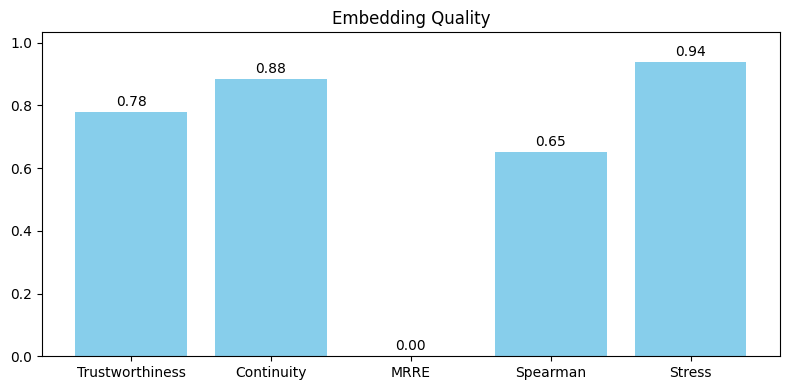

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr

def mean_relative_rank_error(X, Y, k=10):
    """
    Compute MRRE = (1/(N*k)) sum_i sum_{r=1..k} |rank_X(i, j_r) - r|,
    where j_r is the r-th neighbor of i in Y.
    """
    N = X.shape[0]
    nbrsX = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, idxX = nbrsX.kneighbors(X)   # idxX[i,0] == i
    nbrsY = NearestNeighbors(n_neighbors=k+1).fit(Y)
    _, idxY = nbrsY.kneighbors(Y)

    total_err = 0
    for i in range(N):
        # skip the first neighbor (itself)
        for r, j in enumerate(idxY[i,1:], start=1):
            # find rank of j in X‐neighbor list of i
            rank_in_X = np.where(idxX[i] == j)[0][0]
            total_err += abs(rank_in_X - r)
    return total_err / (N * k)

def evaluate_embedding(X, Y, k=10):
    # 1) Trustworthiness
    tw = trustworthiness(X, Y, n_neighbors=k)
    # 2) Continuity via swapped trustworthiness
    ct = trustworthiness(Y, X, n_neighbors=k)
    # 3) MRRE
    # mrre = mean_relative_rank_error(X, Y, k=k)
    mrre = 0

    # 4) Spearman on flattened distance matrices
    D_X = pairwise_distances(X)
    D_Y = pairwise_distances(Y)
    # extract upper‐triangle
    iu = np.triu_indices_from(D_X, k=1)
    sp, _ = spearmanr(D_X[iu], D_Y[iu])
    # 5) Stress
    stress = np.sqrt(np.sum((D_X - D_Y)**2) / np.sum(D_X**2))

    # Print
    print("Embedding Quality Metrics")
    print("-------------------------")
    print(f"Trustworthiness (k={k}):       {tw:.4f}")
    print(f"Continuity      (k={k}):       {ct:.4f}")
    print(f"Mean Rel. Rank Error (k={k}):  {mrre:.4f}")
    print(f"Spearman ρ (all pairs):        {sp:.4f}")
    print(f"Stress (global distortion):    {stress:.4f}\n")

    # Bar chart
    names  = ["Trustworthiness","Continuity","MRRE","Spearman","Stress"]
    vals   = [tw, ct, mrre, sp, stress]
    plt.figure(figsize=(8,4))
    bars = plt.bar(names, vals, color="skyblue")
    plt.ylim(0, max(vals)*1.1)
    for bar, v in zip(bars, vals):
        plt.text(bar.get_x()+bar.get_width()/2, v+0.02*max(vals),
                 f"{v:.2f}", ha="center")
    plt.title("Embedding Quality")
    plt.tight_layout()
    plt.show()

# ─── Usage example ──────────────────────────
# Suppose you have:
#    X = vectors_np           # shape (N, D)
#    coords_pca  or coords_umap  # your (N, 2) embedding
# Then simply call:
evaluate_embedding(vectors_np, coords_pca, k=10)
evaluate_embedding(vectors_np, coords_umap, k=10)
evaluate_embedding(vectors_np, coords, k=10)

In [35]:
import numpy as np

# Assumes you have in scope:
#    path         # list of subgraph node indices defining your shortest path
#    mapping      # list mapping subgraph indices to original indices
#    vectors_np   # numpy array of shape (N, D) with original vectors

line_equations = []  # will hold (node_index, prev_line, next_line)
for k in range(1, len(path)-1):
    i_prev, i_cur, i_next = path[k-1], path[k], path[k+1]
    # original-space vectors
    v_prev = vectors_np[mapping[i_prev]]
    v_cur  = vectors_np[mapping[i_cur]]
    v_next = vectors_np[mapping[i_next]]
    # direction vectors
    dir_prev = v_cur - v_prev
    dir_next = v_next - v_cur
    # store equations
    line_equations.append({
        "node": i_cur,
        "prev_line": {"origin": v_prev, "direction": dir_prev},
        "next_line": {"origin": v_cur,  "direction": dir_next}
    })

# Pretty‐print the first 5 equations
for eq in line_equations[:5]:
    node = eq["node"]
    o1, d1 = eq["prev_line"]["origin"], eq["prev_line"]["direction"]
    o2, d2 = eq["next_line"]["origin"], eq["next_line"]["direction"]
    print(f"Node (subgraph idx) {node}:")
    print(f"  Line from prev → cur:")
    print(f"    x(t) = o + t·d,")
    print(f"    origin o = {o1}")
    print(f"    direction d = {d1}\n")
    print(f"  Line from cur → next:")
    print(f"    x(t) = o + t·d,")
    print(f"    origin o = {o2}")
    print(f"    direction d = {d2}\n")


Node (subgraph idx) 1:
  Line from prev → cur:
    x(t) = o + t·d,
    origin o = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.

In [36]:
import numpy as np

# — Assumes you’ve already defined:
#    path         # list of node indices in the subgraph path
#    mapping      # list mapping subgraph indices → original indices
#    vectors_np   # numpy array of shape (N, D)

print("Zero-change dimensions for each path segment:\n")
for k in range(1, len(path) - 1):
    i_prev, i_cur, i_next = path[k - 1], path[k], path[k + 1]
    # Original-space vectors
    v_prev = vectors_np[mapping[i_prev]]
    v_cur  = vectors_np[mapping[i_cur]]
    v_next = vectors_np[mapping[i_next]]
    # Direction vectors
    dir_prev = v_cur - v_prev
    dir_next = v_next - v_cur
    # Dimensions that never change (zero component)
    non_zeros_prev = np.where(dir_prev != 0)[0]
    non_zeros_next = np.where(dir_next != 0)[0]
    # Output
    print(f"At subgraph node {i_cur}:")
    print(f"  Prev→Cur: {len(non_zeros_prev)} changed dims → {non_zeros_prev.tolist()}")
    print(f"  Cur→Next: {len(non_zeros_next)} changed dims → {non_zeros_next.tolist()}\n")


Zero-change dimensions for each path segment:

At subgraph node 1:
  Prev→Cur: 35 changed dims → [244, 245, 248, 270, 271, 272, 275, 276, 296, 297, 298, 323, 324, 328, 350, 351, 355, 377, 378, 382, 404, 409, 435, 436, 462, 538, 564, 565, 594, 595, 596, 622, 623, 649, 650]
  Cur→Next: 24 changed dims → [162, 163, 189, 190, 191, 192, 216, 217, 218, 243, 247, 248, 274, 275, 276, 296, 301, 323, 350, 377, 539, 621, 651, 678]

At subgraph node 116:
  Prev→Cur: 24 changed dims → [162, 163, 189, 190, 191, 192, 216, 217, 218, 243, 247, 248, 274, 275, 276, 296, 301, 323, 350, 377, 539, 621, 651, 678]
  Cur→Next: 21 changed dims → [162, 164, 220, 269, 323, 350, 377, 381, 458, 462, 512, 516, 539, 566, 570, 597, 598, 624, 625, 652, 677]

At subgraph node 108:
  Prev→Cur: 21 changed dims → [162, 164, 220, 269, 323, 350, 377, 381, 458, 462, 512, 516, 539, 566, 570, 597, 598, 624, 625, 652, 677]
  Cur→Next: 23 changed dims → [135, 136, 161, 162, 188, 215, 220, 242, 296, 327, 381, 435, 458, 489, 512, 5

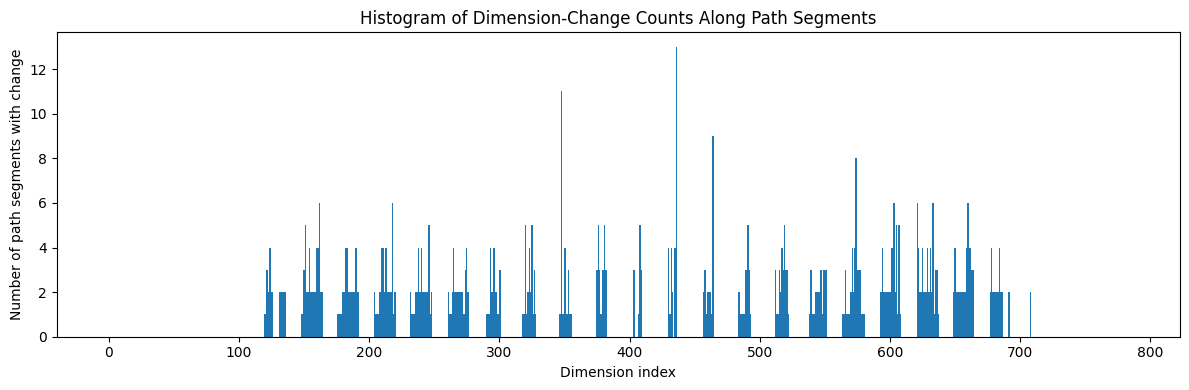

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Initialize change counters for each dimension
D = vectors_np.shape[1]
change_counts = np.zeros(D, dtype=int)

# 2) Iterate over each consecutive segment in the path
for k in range(len(path) - 1):
    idx_prev = mapping[path[k]]
    idx_next = mapping[path[k + 1]]
    diff = vectors_np[idx_next] - vectors_np[idx_prev]
    changed_dims = np.nonzero(diff)[0]
    change_counts[changed_dims] += 1

# 3) Plot histogram of change counts per dimension
plt.figure(figsize=(12, 4))
plt.bar(np.arange(D), change_counts, width=1.0)
plt.xlabel("Dimension index")
plt.ylabel("Number of path segments with change")
plt.title("Histogram of Dimension-Change Counts Along Path Segments")
plt.tight_layout()
plt.show()


A representative path maybe one that most matches the dimensions change throughout the whole graph? If it matches the shape of dimension changes, then surely it must say something about the manifold?

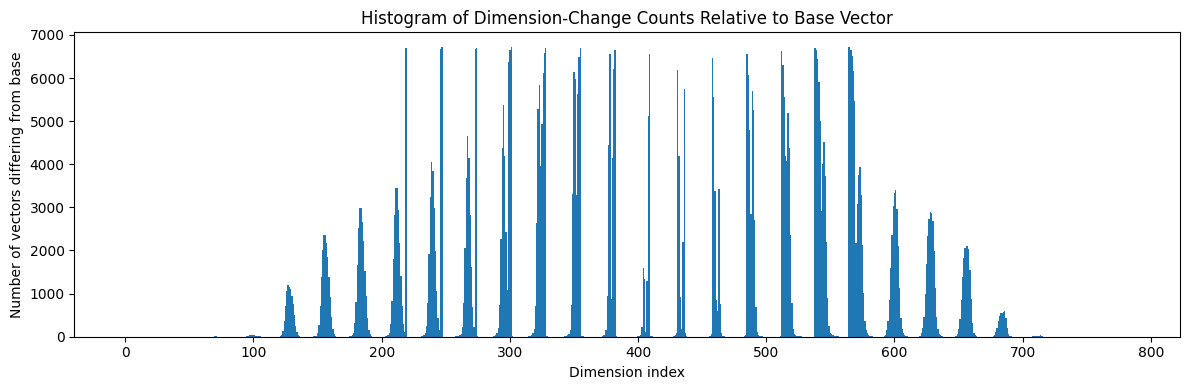

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Choose an arbitrary base vector (e.g., the first one)
base_vector = vectors_np[0]  # shape (D,)

# 2) Compare every vector to the base and count changes per dimension
# A change is where the component differs from the base_vector
change_counts = np.sum(vectors_np != base_vector, axis=0)  # shape (D,)

# 3) Plot histogram of change counts per dimension
D = vectors_np.shape[1]
plt.figure(figsize=(12, 4))
plt.bar(np.arange(D), change_counts, width=1.0)
plt.xlabel("Dimension index")
plt.ylabel("Number of vectors differing from base")
plt.title("Histogram of Dimension-Change Counts Relative to Base Vector")
plt.tight_layout()
plt.show()


In [39]:
import numpy as np

# — Assumes you have already defined:
#    path       # list of subgraph node indices defining your shortest path
#    mapping    # list mapping subgraph subgraph-index → original index
#    vectors_np # numpy array of shape (N, D)

# 1) Build direction vectors for each consecutive path segment
dir_list = []
for k in range(len(path) - 1):
    i1, i2 = path[k], path[k + 1]
    v1 = vectors_np[mapping[i1]]
    v2 = vectors_np[mapping[i2]]
    dir_list.append(v2 - v1)
dirs = np.vstack(dir_list)  # shape (num_segments, D)

# 2) Find dimensions that never change (zero across all segments)
unchanged_dims = np.where(np.all(dirs == 0, axis=0))[0]
changed_dims = np.where(np.any(dirs != 0, axis=0))[0]

# 3) Output results
print(f"Total dimensions D = {vectors_np.shape[1]}")
print(f"Number of globally unchanged dimensions along the path: {len(unchanged_dims)}")
print("Number of globally changed dimensions:", vectors_np.shape[1]-len(unchanged_dims))
print("Unchanged dimension indices:", unchanged_dims.tolist())


Total dimensions D = 784
Number of globally unchanged dimensions along the path: 513
Number of globally changed dimensions: 271
Unchanged dimension indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 127, 128, 129, 130, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 28

In [40]:
path_vectors = []
for k in range(len(path)):
    i1 = path[k]
    v1 = vectors_np[mapping[i1]]
    path_vectors.append(v1)

path_vectors = np.vstack(path_vectors)
path_vectors.shape

(39, 784)

In [41]:
import numpy as np
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression

# Suppose:
#   path = an (n × 784) array of your binary‐MNIST “1” points in path order
#   dims = sorted list of the pixel‐indices that actually change along that path
#   n = len(path)

# 1) Build your “t” coordinate (just the step‐index along the path)
t = np.arange(len(path)).reshape(-1, 1)       # shape = (n,1)

# 2) Set up a degree-3 spline basis
#    n_knots controls flexibility; e.g. choose 5–10 knots for smoothing,
#    or set n_knots=n if you really want exact interpolation (but beware overfitting).
spline_basis = SplineTransformer(
    degree=3,
    n_knots=8,            # ← adjust this: more knots → more wiggle
    include_bias=False,   # leave off the constant term (you’ll get it from LinearRegression)
    knots='quantile'      # place knots at quantiles of t
)

# 3) Fit the basis transform on your t
X_basis = spline_basis.fit_transform(t)        # shape = (n, n_knots+degree-1)

# 4) For each changing dimension j, fit a fast linear model
splines = {}
for j in changed_dims:
    y = path_vectors[:, j]                             # shape = (n,)
    lr = LinearRegression(fit_intercept=True)
    lr.fit(X_basis, y)                         # finds weights β so that β·N(t_i) ≈ y_i
    splines[j] = (spline_basis, lr)

# 5) Now you can evaluate S_j at any new t values:
def eval_spline(j, t_new):
    T = np.array(t_new).reshape(-1,1)
    basis = splines[j][0].transform(T)
    return splines[j][1].predict(basis)

# Example: sample halfway between step 10 and 11 for pixel j=123
print(eval_spline(123, [10.5]))


[0.02709211]


In [42]:
from scipy.interpolate import CubicSpline

t = np.arange(len(path))
cubicSplines = []

for j in changed_dims:
    cs_j = CubicSpline(t, path_vectors[:, j], bc_type='natural')
    # then cs_j(10.5) gives the exact cubic‐spline interpolation at t=10.5
    cubicSplines.append(cs_j)


scipy is quicker but a little bit extra storage for each adjacent pair of points per dimension. scikitlearn is slower but learns an overall curve for each dimension

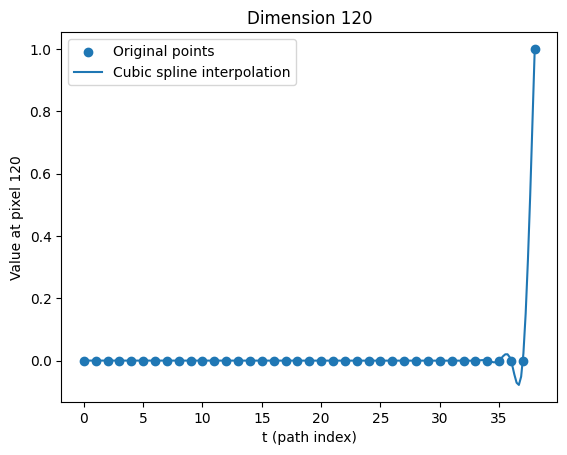

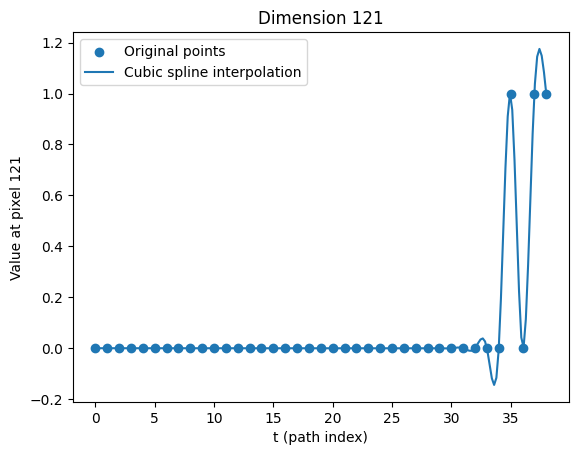

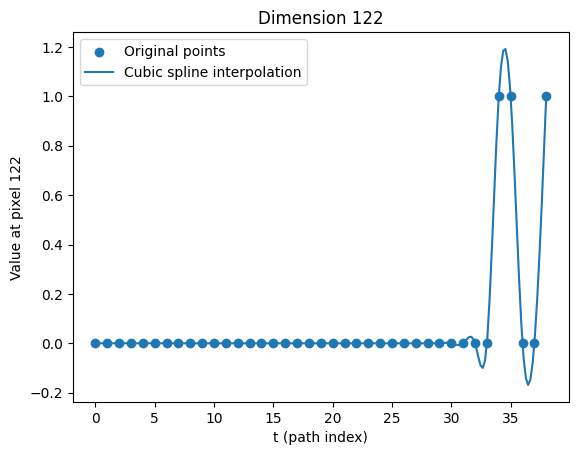

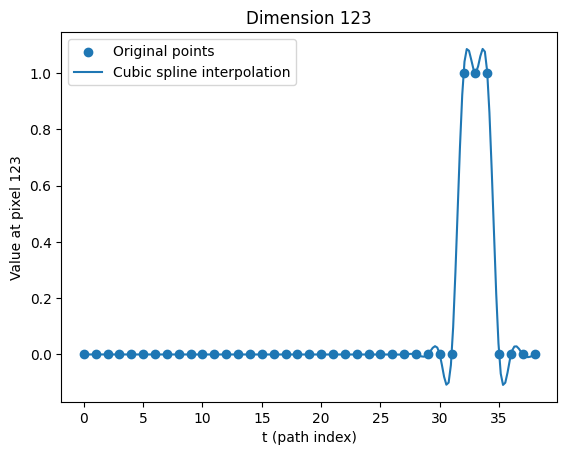

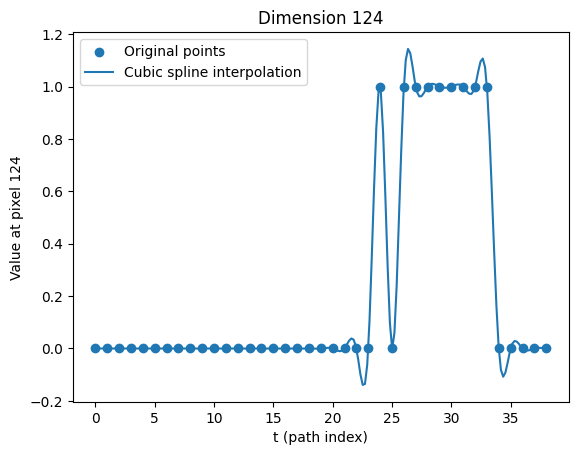

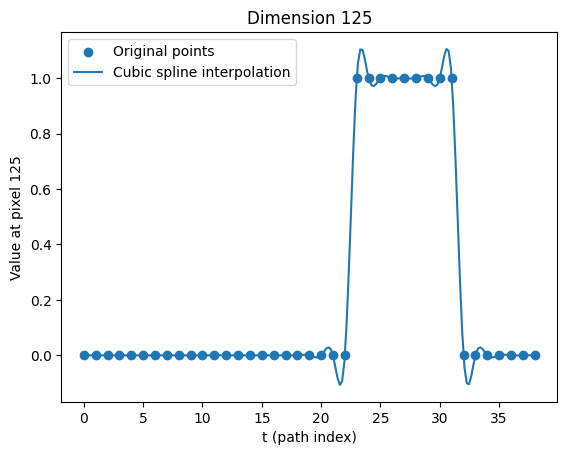

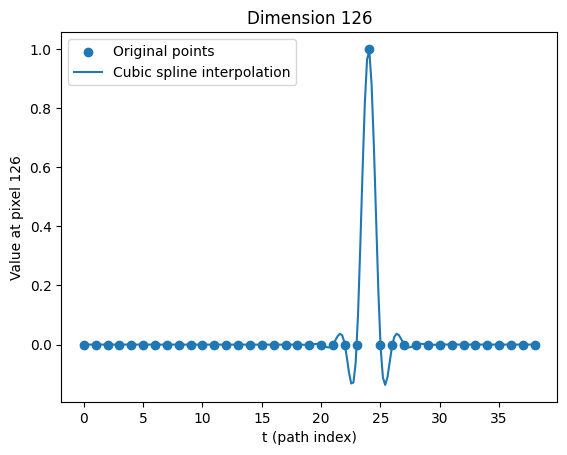

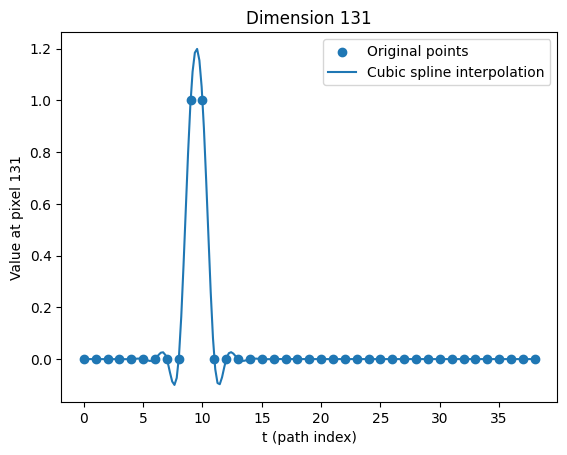

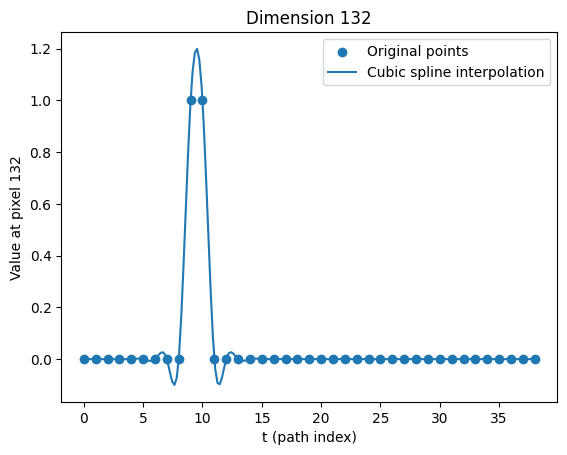

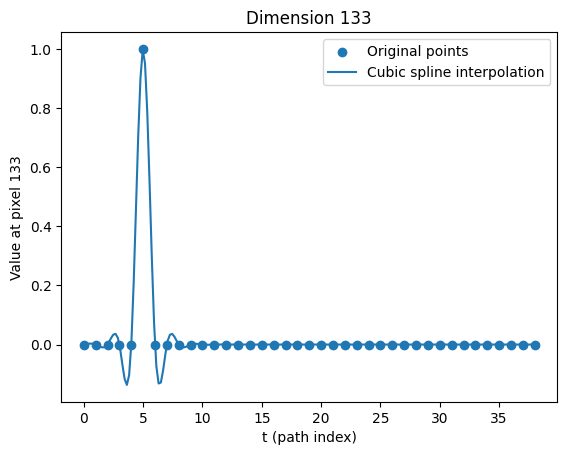

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming t, path_vectors, changed_dims, and cubicSplines are already defined in your environment

# Plot the first three splines
for j, cs_j in zip(changed_dims[:10], cubicSplines[:10]):
    plt.figure()
    plt.scatter(t, path_vectors[:, j], label="Original points")
    ts_fine = np.linspace(t[0], t[-1], 200)
    plt.plot(ts_fine, cs_j(ts_fine), label="Cubic spline interpolation")
    plt.title(f"Dimension {j}")
    plt.xlabel("t (path index)")
    plt.ylabel(f"Value at pixel {j}")
    plt.legend()
    plt.show()


In [ ]:
cs = CubicSpline(t, path_vectors[:, changed_dims], axis=0, bc_type='natural')
cs(10.5)

In [54]:
cs = CubicSpline(np.arange(len(vectors_np)), vectors_np, axis=0, bc_type='natural')
cs(10.5)

array([ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,